<a href="https://colab.research.google.com/github/NilayKnt/Machine-Learning-Applications/blob/main/%C3%A7al%C4%B1%C5%9Fma_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.manifold import TSNE

from sklearn.metrics import silhouette_score,davies_bouldin_score,calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram,linkage

In [69]:
df = pd.read_csv("Mall_Customers.csv")
print(f"veri boyutu:{df.shape}")
df.info()



veri boyutu:(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [50]:
df.isnull().sum()

,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [51]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.0,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.0,99.0


In [52]:
scaler = StandardScaler()

# Select only numerical columns for scaling
df_imputed_numeric = df_imputed.select_dtypes(include=np.number)

X_scaled = scaler.fit_transform(df_imputed_numeric)
df_scaled = pd.DataFrame(X_scaled, columns=df_imputed_numeric.columns, index=df_imputed_numeric.index)
df_scaled.head(2)

,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,
1,-1.424569,-1.738999,-0.434801
2,-1.281035,-1.738999,1.195704


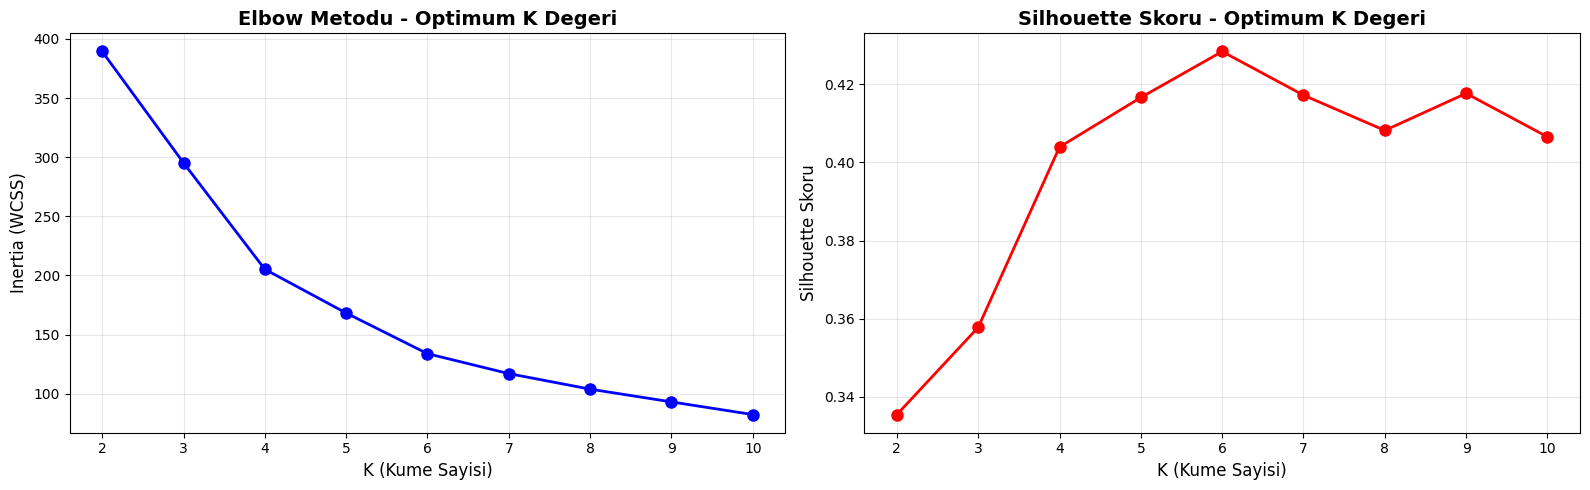

En iyi silhoutte skoru: 0.4284
Optimum K degeri: 6


In [53]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Gorsellestirme
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Metodu - Optimum K Degeri', fontsize=14, fontweight='bold')
axes[0].set_xlabel('K (Kume Sayisi)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Skoru - Optimum K Degeri', fontsize=14, fontweight='bold')
axes[1].set_xlabel('K (Kume Sayisi)', fontsize=12)
axes[1].set_ylabel('Silhouette Skoru', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f'En iyi silhoutte skoru: {max(silhouette_scores):.4f}')
print(f'Optimum K degeri: {optimal_k}')

In [54]:
optimal_k = 3  # Elbow ve silhouette analizine gore
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print('K-Means Kumeleme Sonuclari:')
print(f'Kume sayisi: {optimal_k}')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, kmeans_labels):.4f}')
print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, kmeans_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, kmeans_labels):.4f}')
print(f'\nKume dagilimi:')
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means Kumeleme Sonuclari:
Kume sayisi: 3
Silhouette Skoru: 0.3578
Davies-Bouldin Indeksi: 1.0503
Calinski-Harabasz Skoru: 101.6949

Kume dagilimi:
0    68
1    41
2    91
Name: count, dtype: int64


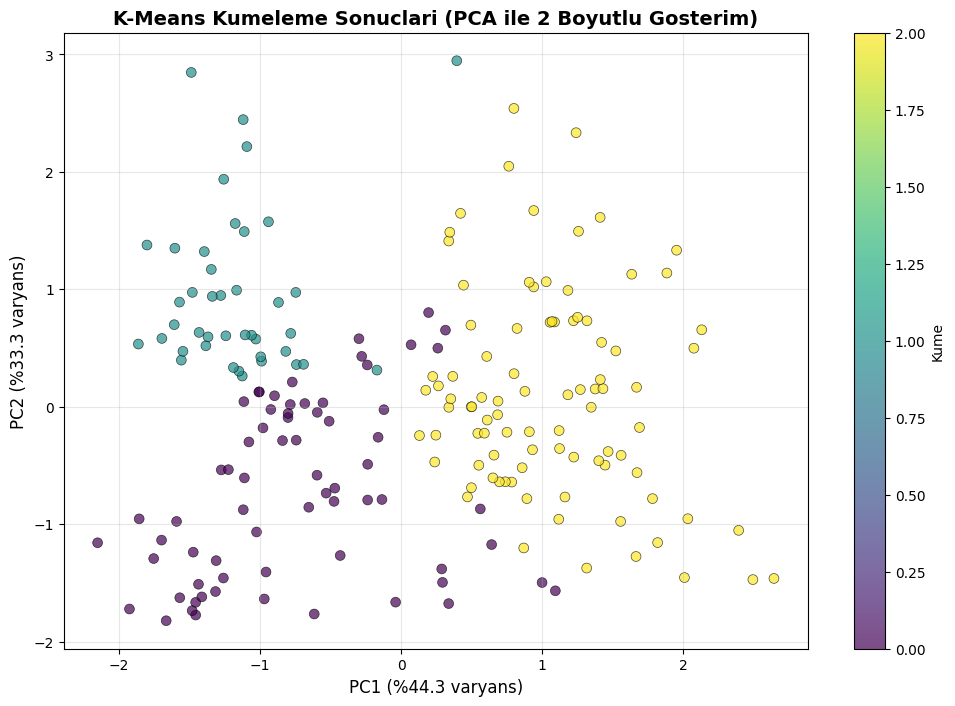

In [55]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('K-Means Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

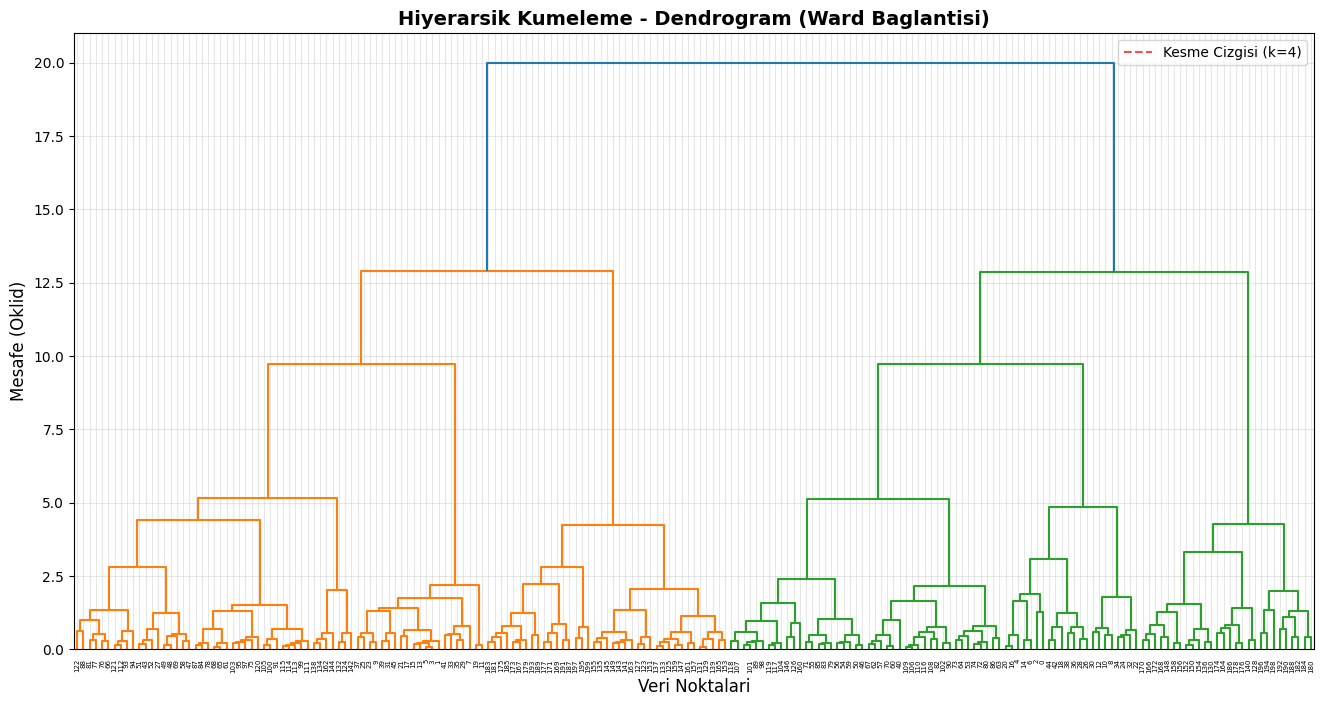

In [56]:
plt.figure(figsize=(16, 8))
linked = linkage(X_scaled[:200], method='ward')  # Gorsellestirme icin 200 ornek
dendrogram(linked, orientation='top', distance_sort='descending',
           show_leaf_counts=False, truncate_mode='level', p=10)
plt.title('Hiyerarsik Kumeleme - Dendrogram (Ward Baglantisi)', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktalari', fontsize=12)
plt.ylabel('Mesafe (Oklid)', fontsize=12)
plt.axhline(y=30, color='r', linestyle='--', alpha=0.7, label='Kesme Cizgisi (k=4)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [57]:
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_scaled)

print('Hiyerarsik Kumeleme (Agglomerative) Sonuclari:')
print(f'Kume sayisi: {optimal_k}')
print(f'Baglanti yontemi: ward')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, agg_labels):.4f}')
print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, agg_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, agg_labels):.4f}')
print(f'\nKume dagilimi:')


Hiyerarsik Kumeleme (Agglomerative) Sonuclari:
Kume sayisi: 3
Baglanti yontemi: ward
Silhouette Skoru: 0.3215
Davies-Bouldin Indeksi: 1.1277
Calinski-Harabasz Skoru: 88.1017

Kume dagilimi:


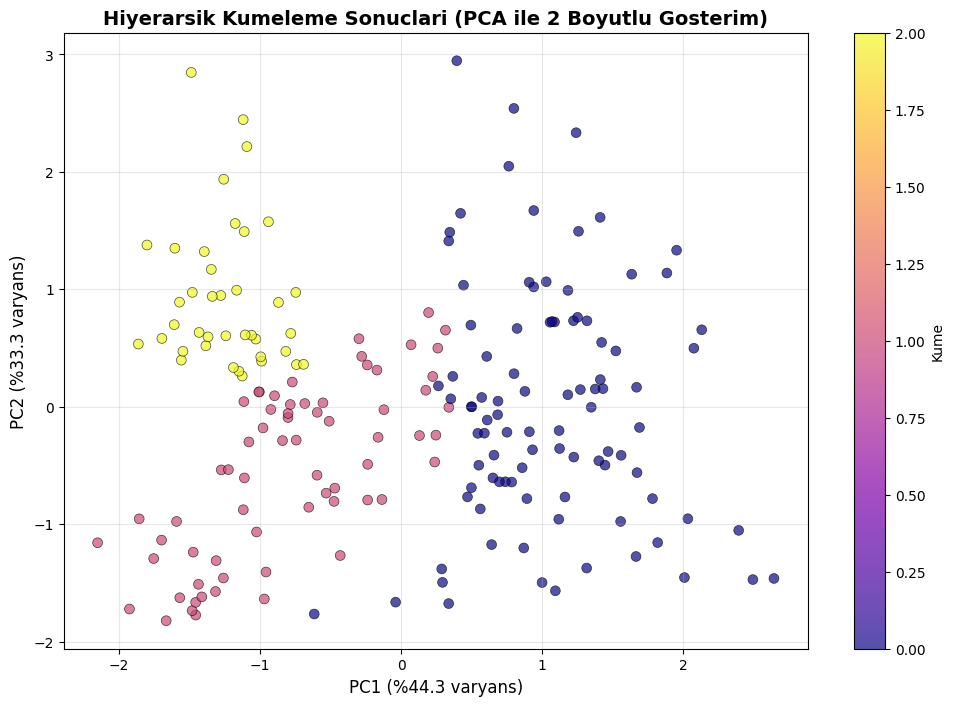

In [58]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='plasma',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('Hiyerarsik Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

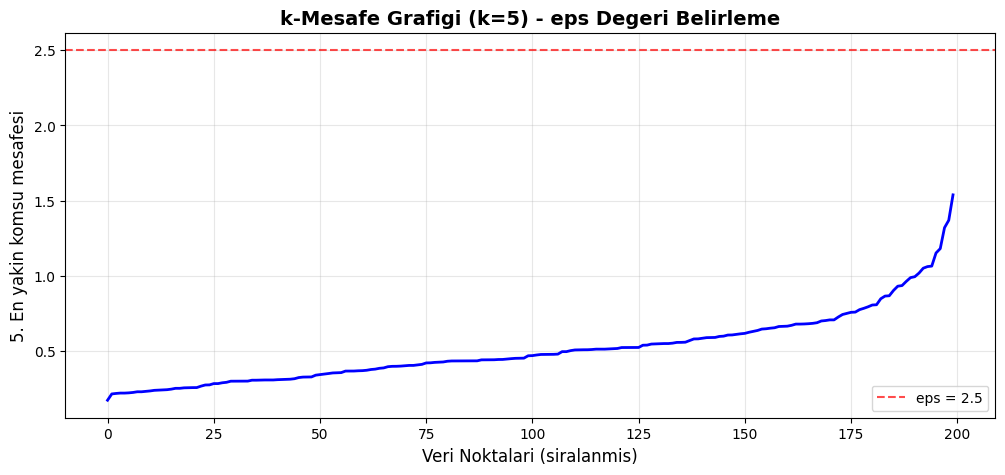

In [59]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(12, 5))
plt.plot(distances, 'b-', linewidth=2)
plt.title('k-Mesafe Grafigi (k=5) - eps Degeri Belirleme', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktalari (siralanmis)', fontsize=12)
plt.ylabel('5. En yakin komsu mesafesi', fontsize=12)
plt.axhline(y=2.5, color='r', linestyle='--', alpha=0.7, label='eps = 2.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [60]:
dbscan = DBSCAN(eps=2.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print('DBSCAN Kumeleme Sonuclari:')
print(f'eps: 2.5, min_samples: 5')
print(f'Olusan kume sayisi: {n_clusters_db}')
print(f'Gurultu (aykiri deger) sayisi: {n_noise}')
print(f'Gurultu orani: {n_noise/len(dbscan_labels)*100:.2f}%')

if n_clusters_db > 1:
    print(f'Silhouette Skoru: {silhouette_score(X_scaled, dbscan_labels):.4f}')
    print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, dbscan_labels):.4f}')
    print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, dbscan_labels):.4f}')

print(f'\nKume dagilimi:')
print(pd.Series(dbscan_labels).value_counts().sort_index())


DBSCAN Kumeleme Sonuclari:
eps: 2.5, min_samples: 5
Olusan kume sayisi: 1
Gurultu (aykiri deger) sayisi: 0
Gurultu orani: 0.00%

Kume dagilimi:
0    200
Name: count, dtype: int64


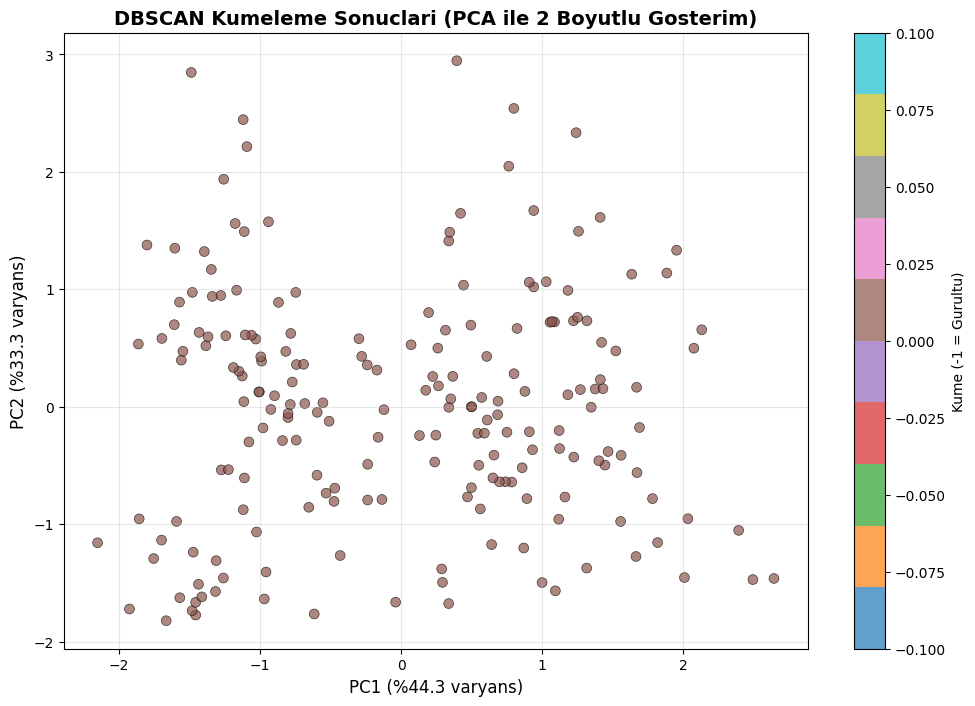

In [61]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='tab10',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume (-1 = Gurultu)')
plt.title('DBSCAN Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [62]:
import random
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold,cross_val_score
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import (accuracy_score,classification_report,ConfusionMatrixDisplay,RocCurveDisplay)

In [63]:
SEED=42
random.seed(SEED)
np.random.seed()


data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [64]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
dt_grid= GridSearchCV(DecisionTreeClassifier(random_state=SEED),
                      param_grid={
                          "criterion":["gini","entropy"],
                          "splitter":["best","random"],
                          "max_depth":[3,4,5,6,8,None],
                          "min_samples_leaf" :[1,2,5,10]
                      },
                      cv=cv ,scoring="accuracy",n_jobs=-1)
dt_grid.fit(X_train,y_train)
dt=dt_grid.best_estimator_
print("En iyi parametre:", dt_grid.best_params_)

En iyi parametre: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 5, 'splitter': 'random'}


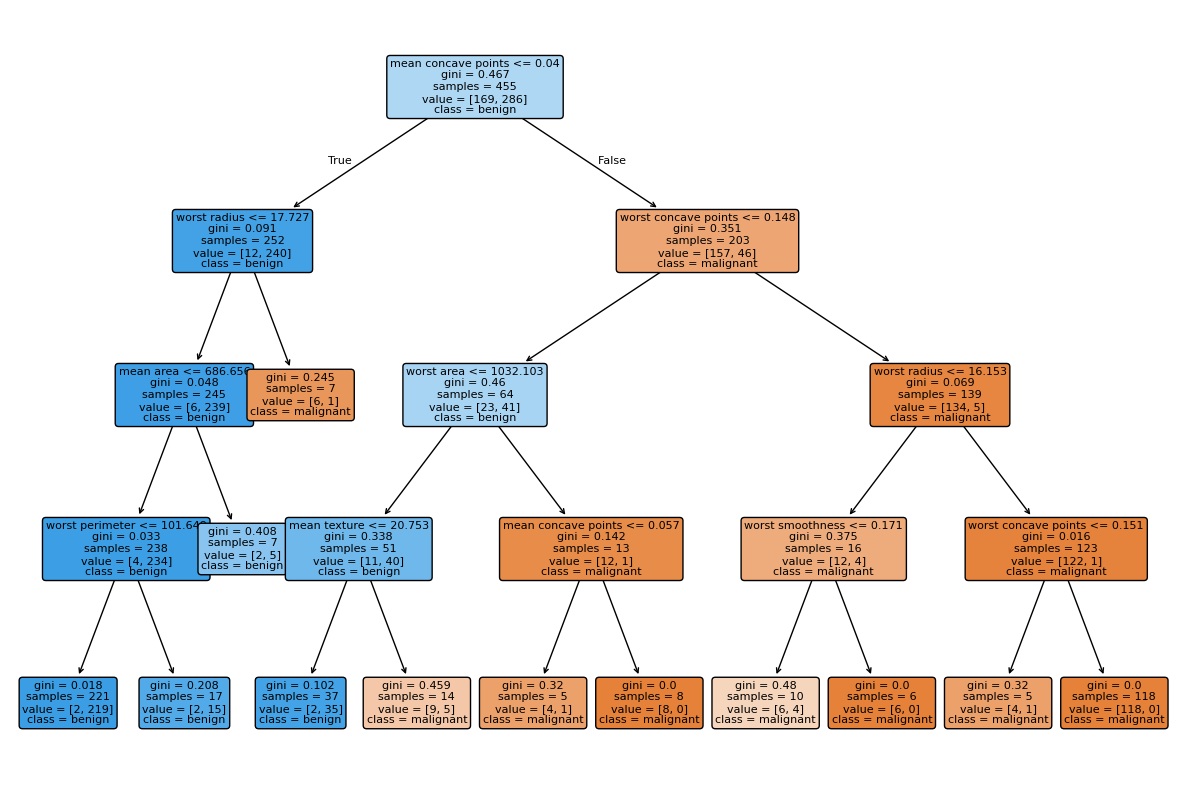

In [65]:
plt.figure(figsize=(15,10))
plot_tree(dt,feature_names=data.feature_names,class_names=data.target_names,
          filled=True,rounded= True, max_depth= 8, fontsize =8)

plt.show()

In [66]:
from sklearn.ensemble import RandomForestClassifier
rf_grid= GridSearchCV(RandomForestClassifier(random_state=SEED),
                      param_grid={
                          "n_estimators":[100,200],
                          "max_depth":[5,7],
                          "min_samples_leaf" :[1,2],
                          "min_samples_split":[2,5],
                          "max_features":["sqrt","log2"],
                          "criterion":["gini","entropy"],
                          "bootstrap":[True,False]
                      },
                      cv=cv ,scoring="accuracy",n_jobs=-1,verbose =3)
rf_grid.fit(X_train,y_train)
rf=rf_grid.best_estimator_
print("En iyi parametre:", rf_grid.best_params_)

Fitting 5 folds for each of 128 candidates, totalling 640 fits
En iyi parametre: {'bootstrap': False, 'criterion': 'entropy', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [67]:
for name,model in [("Decision Tree" ,dt),("Random Forest",rf)]:
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    cv_scores=cross_val_score(model,X_train,y_train,cv=cv,scoring="accuracy")
    print(f"========{"Test"}========")
    print(f"Test doğruluğu:{accuracy_score(y_test,y_pred)}")
    print(f"Ortalama 5 katlı CV doğruluğu:{np.mean(cv_scores)}")

========Test========
Test doğruluğu:0.9473684210526315
Ortalama 5 katlı CV doğruluğu:0.9472527472527472
========Test========
Test doğruluğu:0.9649122807017544
Ortalama 5 katlı CV doğruluğu:0.964835164835165


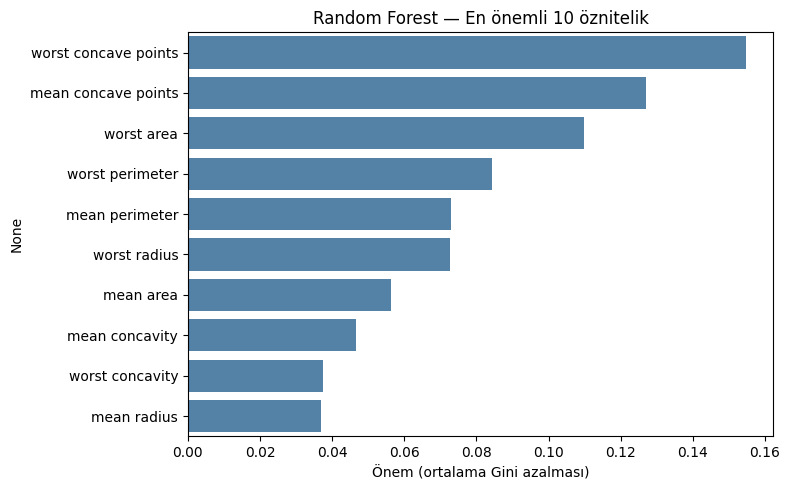

Grafikler kaydedildi: decision_tree.png, confusion_roc.png, feature_importance.png


In [68]:
imp = pd.Series(rf.feature_importances_, index=data.feature_names).nlargest(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=imp.values, y=imp.index, color="steelblue")
plt.xlabel("Önem (ortalama Gini azalması)")
plt.title("Random Forest — En önemli 10 öznitelik")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print("Grafikler kaydedildi: decision_tree.png, confusion_roc.png, feature_importance.png")